### Cross Validation

Cross-validation is a technique to evaluate how well a model generalizes to unseen data, by testing it on data it was not trained on.

The core idea is to split the data into **k equal parts (folds)**. The model trains on k-1 folds and is tested on the remaining fold. This repeats k times, each time with a different fold as the test set. The scores from all k rounds are then averaged to produce a reliable performance estimate.

This is more trustworthy than a single train/test split because a single split can get lucky or unlucky depending on how the data was divided. Averaging over k splits cancels that noise out.

**Example with k=5:**

- Round 1: test on fold 1, train on folds 2,3,4,5
- Round 2: test on fold 2, train on folds 1,3,4,5
- Round 3: test on fold 3, train on folds 1,2,4,5
- Round 4: test on fold 4, train on folds 1,2,3,5
- Round 5: test on fold 5, train on folds 1,2,3,4

Final score = average of all 5 test scores

**In hyperparameter tuning (GridSearchCV):**

Each hyperparameter combination gets its own full k-fold evaluation. The combination with the highest average CV score is selected as the best. This way, the test set is never involved in the tuning process — it stays locked away for a final honest evaluation at the end.

#### K-Fold Cross Validation

In K-fold cross-validation, the available data is divided into k equal parts or 'folds'. The model is then trained on k-1 of the folds and validated on the remaining fold. This process is repeated k times, with each fold being used once as the validation set. The results from each fold are then averaged to obtain an overall estimate of model's performance.

- In Summary, cross-validation is a powerful technique for evaluating the performance of machine learning models and can help to ensure that our models are accurate, reliable, and able to generalize to new data.

### Types of CV

- K-fold cross validation
- Train-test split
- Leave-one-out cross-validation
- Stratified cross-validation
- Time series cross-validation
- Group cross-validation

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB

iris = load_iris()

# Define the Guassian Naive Bayes model
nb = GaussianNB()

# cross_val_score handles everything internally:
# - splits data into 5 folds
# - trains nb on 4 folds, tests on 1 (repeated 5 times)
# - returns accuracy score for each fold
# nb here is just the blueprint, the function trains it 5 times behind the scenes

# perform k-fold cross validation with k=5
scores = cross_val_score(nb, iris.data, iris.target, cv=5, scoring='accuracy')

print("Scores for each fold: ", scores)
print("Mean Score: ", scores.mean())
print("Standard Deviation: ", scores.std())

Scores for each fold:  [0.93333333 0.96666667 0.93333333 0.93333333 1.        ]
Mean Score:  0.9533333333333334
Standard Deviation:  0.02666666666666666


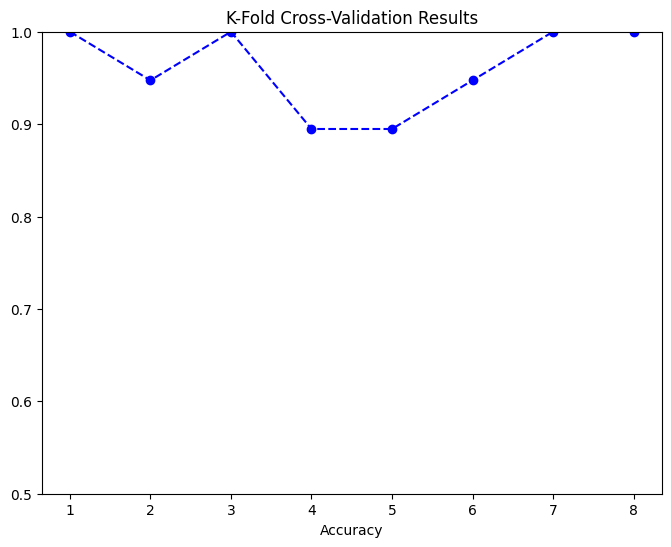

In [4]:
#### How to plot K-fold CV
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X = iris.data
y = iris.target

clf = DecisionTreeClassifier()

scores = cross_val_score(clf, X, y, cv=8)

plt.figure(figsize=(8,6))
plt.plot(range(1,9), scores, color='blue', linestyle='dashed', marker='o')
plt.title('K-Fold Cross-Validation Results')
plt.xlabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.show()